<a href="https://colab.research.google.com/github/AcSsalazar/the-color-of-emotions/blob/main/Notebooks/5.2-model-training-with-agumentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Fine-Tuning con ResNet-18 y EfficientNet-B0

### Introducción: PNG vs. Tensor

Esta es la instancia previa a la elección del mejor modelo para el **Reconocimiento de Emociones en el Habla (SER)**. En este notebook, se entrenarán modelos utilizando dos enfoques de entrada distintos:

1.  **Imágenes (PNG):** Espectrogramas de Mel generados y guardados previamente como archivos de imagen.
2.  **Tensores 3D:** Datos procesados directamente con PyTorch a partir de los **Coeficientes Cepstrales (MFCCs)** y sus **Deltas de primer y segundo orden**. Esto resulta en un tensor de entrada con la estructura `[3, Frecuencia, Tiempo]`.

Analizaremos las métricas de rendimiento, los costos computacionales y, por sobre todo, el alcance de los modelos cuyos datos de entrada fueron imágenes comprimidas en comparación con aquellos entrenados con tensores, los cuales conservan de manera más íntegra la información y la dimensión temporal en sus entradas.

In [ ]:
# Imports
#----------------------------------------------------------------
import gc
import glob
import torch
import random
import torch.nn as nn
import seaborn as sns
import torch.optim as optim
import matplotlib.pyplot as plt
#----------------------------------------------------------------
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import datasets, transforms, models
from PIL import Image
from sklearn.utils.extmath import device
from sklearn.metrics import classification_report, confusion_matrix
from torch.cuda.amp import GradScaler, autocast
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Optimizaciones de hardware y fijación de semillas para reproducibilidad
torch.manual_seed(42)
torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device en uso: {device}")

Device en uso: cuda


In [ ]:
# Copiamos la carpeta entera de features desde Drive al disco ultrarrápido de Colab
#!cp -r /content/drive/MyDrive/ravdess_images_02/ /content/features_local
os.makedirs('/content/ravdess_and_crema_images', exist_ok=True)
# Opcional: Si tienes un archivo .zip en Drive, es AÚN MÁS RÁPIDO copiar el .zip y descomprimirlo localmente:
!cp /content/drive/MyDrive/mel_spec_mfcc_images.zip /content/mel_spec_mfcc_images.zip
!unzip -q /content/mel_spec_mfcc_images.zip -d /content/ravdess_and_crema_images

replace /content/ravdess_and_crema_images/mel_spec/test/angry/c_1023_DFA_ANG_XX.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [ ]:
# Configuraciones y rutas

BASE_DIR = '/content/ravdess_and_crema_images'
MODELS_SAVE_DIR = '/content/saved_models'
os.makedirs(MODELS_SAVE_DIR, exist_ok=True)

BATCH_SIZE = 64 # Ajustable si hay problemas de memoria con DenseNet (Spoiler: Dejar en 64)

# Se recomienda usar la GPU que ofrece Google Colab para acelerar el entrenamiento
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Dataloaders desde datos con split (Train, Validation, Test)

In [ ]:
def get_dataloaders(feature_type):
    """
    Construye DataLoaders aislando Train/Val/Test.
    Aplica normalización de ImageNet estrictamente necesaria para el Transfer Learning.
    Nota: ImageFolder convierte automáticamente RGBA a RGB (fondo negro) por defecto.
    """
    feature_dir = os.path.join(BASE_DIR, feature_type)

    transform_pipeline = transforms.Compose([
        #transforms.Resize(224,224), # Cambiar si la imagen de origen no es 224x224
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    datasets_dict = {}
    for split in ['train', 'val', 'test']:
        split_path = os.path.join(feature_dir, split)
        datasets_dict[split] = datasets.ImageFolder(root=split_path, transform=transform_pipeline)

    # Optimizaciones: num_workers=2 y pin_memory=True aceleran la transferencia a la GPU
    train_loader = DataLoader(datasets_dict['train'], batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(datasets_dict['val'], batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(datasets_dict['test'], batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    class_names = datasets_dict['train'].classes
    print(f"[{feature_type.upper()}] Clases detectadas: {class_names}")
    print(f"Muestras -> Train: {len(datasets_dict['train'])} | Val: {len(datasets_dict['val'])} | Test: {len(datasets_dict['test'])}")

    return train_loader, val_loader, test_loader, class_names

In [ ]:
# Print root_dir content:
print(os.listdir(BASE_DIR))

['mfcc', 'mel_spec']


In [ ]:
get_dataloaders('mel_spec')

[MEL_SPEC] Clases detectadas: ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Muestras -> Train: 7435 | Val: 824 | Test: 895


(<torch.utils.data.dataloader.DataLoader at 0x7eca63059fa0>,
 ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised'])

In [ ]:
class ModelFactory:
    @staticmethod
    def get_model(model_name, num_classes, freeze_base=True):
        """
        Instancia dinámicamente arquitecturas convolucionales y adapta la última capa.
        """
        if model_name == 'resnet18':
            model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
            if freeze_base:
                for param in model.parameters(): param.requires_grad = False

            num_ftrs = model.fc.in_features
            model.fc = nn.Sequential(nn.Dropout(0.7), nn.Linear(num_ftrs, num_classes))

        elif model_name == 'efficientnet_b0':
            model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
            if freeze_base:
                for param in model.parameters(): param.requires_grad = False

            num_ftrs = model.classifier[1].in_features
            model.classifier[1] = nn.Sequential(nn.Dropout(0.5), nn.Linear(num_ftrs, num_classes))

        elif model_name == 'densenet121':
            model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
            if freeze_base:
                for param in model.parameters(): param.requires_grad = False

            num_ftrs = model.classifier.in_features
            model.classifier = nn.Sequential(nn.Dropout(0.5), nn.Linear(num_ftrs, num_classes))

        else:
            raise ValueError(f"Arquitectura {model_name} no soportada.")

        return model.to(device)

In [ ]:
def train_model(model, train_loader, val_loader, model_save_name, epochs=15, lr=1e-3, patience=5):
    """
    Bucle de entrenamiento con Mixed Precision (AMP) y Early Stopping y LR Scheduler.
    """
    criterion = nn.CrossEntropyLoss()
    # Optimiza solo los parámetros que requieren gradiente (útil en Phase 1)
    # Incrementamos weight_decay a 1e-2 para combatir el Overfitting observado
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=5e-2)

    # Configuramos el LR(Dinamico): Reduce el LR a la mitad si el val_loss no mejora en 2 épocas
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

    scaler = torch.amp.GradScaler('cuda')

    best_val_loss = float('inf')
    trigger_times = 0
    save_path = os.path.join(MODELS_SAVE_DIR, f'{model_save_name}.pth')

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            # Forward pass con AMP para ahorro de memoria
            with torch.amp.autocast('cuda'):
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_acc = correct / total

        # Phase de Validación
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_loss / val_total
        val_acc = val_correct / val_total

        # Actualizamos el Scheduler basado en la métrica de validación
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']

        print(f"Epoch {epoch+1}/{epochs}[LR:{current_lr:.1e}] | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        # Early Stopping Logic
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), save_path)

        else:
            trigger_times += 1
            print(f"Early stop trigger activado {trigger_times} / {patience}")
            if trigger_times >= patience:
                print(f"--> Early Stopping disparado en época {epoch+1}.")
                break

    return save_path

In [ ]:
# =====================================================================
#
# =====================================================================
MODES = ['vector', 'png']
TARGET_FEATURE = 'mel_spec' # Opciones: 'mel_spec', 'mfcc'
MODEL_ARCHITECTURE = 'efficientnet_b0' # Opciones: 'resnet18', 'densenet121', 'efficientnet_b0'

# Ensure 'device' refers to the torch.device object, not the sklearn function

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Carga de datos (usa los DataLoaders optimizados)
print(f"Cargando datos de: {TARGET_FEATURE.upper()}")
train_loader, val_loader, test_loader, class_names = get_dataloaders(TARGET_FEATURE)

# 2. Construcción dinámica mediante el Model Factory
model = ModelFactory.get_model(model_name=MODEL_ARCHITECTURE, num_classes=len(class_names), freeze_base=True)

experiment_name = f"{TARGET_FEATURE}_{MODEL_ARCHITECTURE}"

# =====================================================================
# FASE 1: TRANSFER LEARNING (Clasificador Superior)
# =====================================================================
print(f"\n--- INICIANDO FASE 1: Entrenando clasificador de {MODEL_ARCHITECTURE} ---")
best_model_path_phase1 = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    model_save_name=f"{experiment_name}_phase1",
    epochs=15,
    lr=1e-3, # LR más alto porque solo entrenamos la capa lineal final
    patience=4
)

# =====================================================================
# FASE 2: FINE-TUNING PROFUNDO (Descongelamiento)
# =====================================================================
print(f"\n--- INICIANDO FASE 2: Fine-Tuning profundo ---")
# Restauramos el modelo al punto de menor pérdida en la Fase 1
model.load_state_dict(torch.load(best_model_path_phase1, weights_only=True))

# Descongelamos TODOS los pesos para que los filtros convolucionales se adapten al audio
for param in model.parameters():
    param.requires_grad = True

best_model_path_phase2 = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    model_save_name=f"{experiment_name}_phase2_unfrozen",
    epochs=40,
    lr=1e-5, # CRÍTICO: LR drásticamente más bajo para no destruir los pesos de ImageNet
    patience=4
)

print(f"\nEntrenamiento Finalizado. Mejor modelo guardado en: {best_model_path_phase2}")

Cargando datos de: MEL_SPEC
[MEL_SPEC] Clases detectadas: ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Muestras -> Train: 7435 | Val: 824 | Test: 895

--- INICIANDO FASE 1: Entrenando clasificador de efficientnet_b0 ---
Epoch 1/15[LR:1.0e-03] | Train Loss: 1.6736 Acc: 0.3251 | Val Loss: 1.5513 Acc: 0.3883
Epoch 2/15[LR:1.0e-03] | Train Loss: 1.5164 Acc: 0.4075 | Val Loss: 1.5039 Acc: 0.4066
Epoch 3/15[LR:1.0e-03] | Train Loss: 1.4786 Acc: 0.4206 | Val Loss: 1.4881 Acc: 0.4053
Epoch 4/15[LR:1.0e-03] | Train Loss: 1.4555 Acc: 0.4292 | Val Loss: 1.4508 Acc: 0.4248
Epoch 5/15[LR:1.0e-03] | Train Loss: 1.4476 Acc: 0.4317 | Val Loss: 1.4620 Acc: 0.4296
Early stop trigger activado 1 / 4
Epoch 6/15[LR:1.0e-03] | Train Loss: 1.4310 Acc: 0.4416 | Val Loss: 1.4559 Acc: 0.4442
Early stop trigger activado 2 / 4
Epoch 7/15[LR:1.0e-03] | Train Loss: 1.4317 Acc: 0.4402 | Val Loss: 1.4305 Acc: 0.4587
Epoch 8/15[LR:1.0e-03] | Train Loss: 1.4314 Acc: 0.4397 | Val Loss: 1.4439 A

Cargando modelo para evaluación: /content/saved_models/mel_spec_efficientnet_b0_phase2_unfrozen.pth

REPORTE DE CLASIFICACIÓN: EFFICIENTNET_B0
              precision    recall  f1-score   support

       angry       0.56      0.72      0.63       144
     disgust       0.49      0.28      0.36       144
     fearful       0.49      0.57      0.52       144
       happy       0.51      0.55      0.53       144
     neutral       0.49      0.60      0.54       143
         sad       0.56      0.36      0.44       144
   surprised       0.69      0.75      0.72        32

    accuracy                           0.52       895
   macro avg       0.54      0.55      0.53       895
weighted avg       0.52      0.52      0.51       895



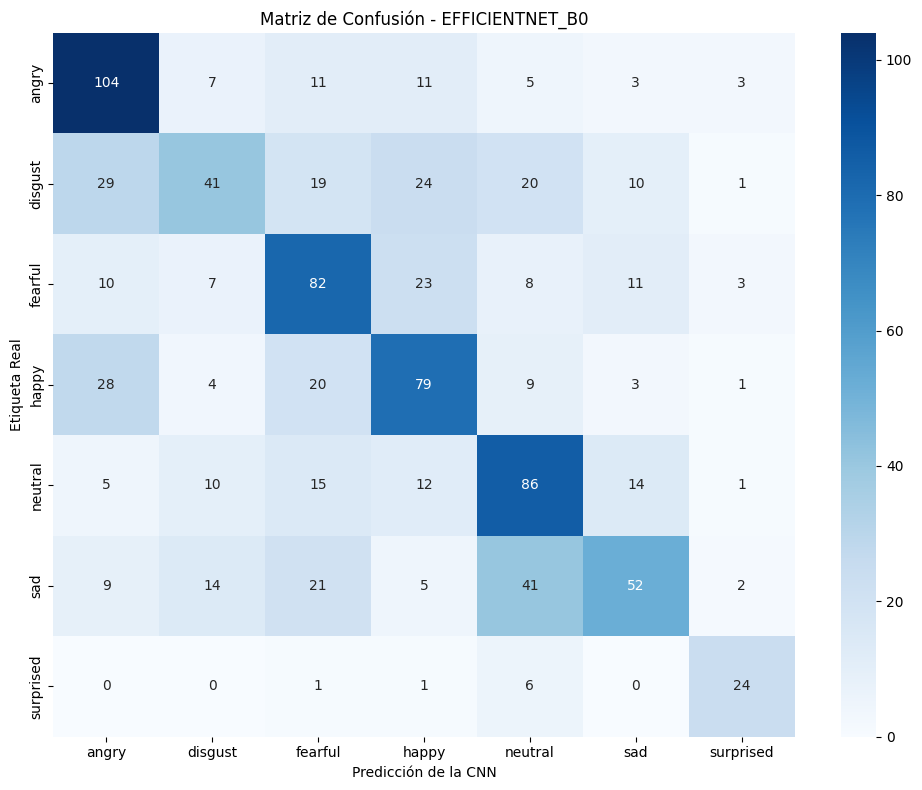

In [ ]:
def evaluate_model(model_path, test_loader, class_names, model_arch):
    """
    Carga los pesos de un modelo entrenado, ejecuta inferencia sobre el Test Set
    y genera métricas de clasificación estandarizadas.
    """
    print(f"Cargando modelo para evaluación: {model_path}")

    # Instanciamos una arquitectura vacía (sin congelar nada) y cargamos los pesos finales
    model = ModelFactory.get_model(model_name=model_arch, num_classes=len(class_names), freeze_base=False)
    model.load_state_dict(torch.load(model_path, weights_only=True))
    model.to(device)
    model.eval() # Modo evaluación: congela capas de Dropout y BatchNorm

    all_preds = []
    all_labels = []

    # Desactivar el tracking de gradientes es obligatorio para liberar VRAM en inferencia
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            # AMP también se usa en inferencia para mayor velocidad
            with torch.amp.autocast('cuda'):
                outputs = model(inputs)
                _, predicted = torch.max(outputs, 1)

            # Data Handling: Scikit-learn requiere arrays en CPU y en Numpy
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # 1. Reporte Estadístico (F1-Score, Precision, Recall)
    print("\n" + "="*60)
    print(f"REPORTE DE CLASIFICACIÓN: {model_arch.upper()}")
    print("="*60)
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # 2. Visualización: Matriz de Confusión
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Matriz de Confusión - {model_arch.upper()}')
    plt.ylabel('Etiqueta Real')
    plt.xlabel('Predicción de la CNN')
    plt.tight_layout()
    plt.show()

    # Memory Management: Limpieza de la GPU tras la inferencia
    del model
    torch.cuda.empty_cache()
    gc.collect()

# Ejecutamos la evaluación con el modelo recién entrenado
evaluate_model(
    model_path=best_model_path_phase2,
    test_loader=test_loader,
    class_names=class_names,
    model_arch=MODEL_ARCHITECTURE
)

In [ ]:

# Define la ruta específica que vas a evaluar ahora
current_path = '/content/drive/MyDrive/models_with_model_factory/best_model_for_mel_spec_efficientnet_b0_unfrozen'
# Prints
print(f"\n{'='*60}")
print(f"Evaluando modelo: {os.path.basename(current_path)}")
print(f"{'='*60}\n")
#Llamado a la funcion evaluadora
evaluate_model(
    model=model,
    model_path=current_path,
    test_loader=test_loader,
    class_names=class_names
)



Evaluando modelo: best_model_for_mel_spec_efficientnet_b0_unfrozen



TypeError: evaluate_model() got an unexpected keyword argument 'model'

In [ ]:
current_path = '/content/drive/MyDrive/models_with_model_factory/best_model_for_mfcc_efficientnet_b0_unfrozen'

print(f"\n{'='*60}")
print(f"Evaluando modelo: {os.path.basename(current_path)}")
print(f"{'='*60}\n")

evaluate_model(
    model=model,
    model_path=current_path,
    test_loader=test_loader,
    class_names=class_names
)

In [ ]:
current_path = '/content/drive/MyDrive/models_with_model_factory/best_model_for_mfcc_densenet121_unfrozen'

print(f"\n{'='*60}")
print(f"Evaluando modelo: {os.path.basename(current_path)}")
print(f"{'='*60}\n")

evaluate_model(
    model=model,
    model_path=current_path,
    test_loader=test_loader,
    class_names=class_names
)

In [ ]:
current_path = '/content/drive/MyDrive/saved_models_ResNet/best_model_for_delta'

print(f"\n{'='*60}")
print(f"Evaluando modelo: {os.path.basename(current_path)}")
print(f"{'='*60}\n")

evaluate_model(
    model=model,
    model_path=current_path,
    test_loader=test_loader,
    class_names=class_names
)

In [ ]:
current_path = '/content/drive/MyDrive/saved_models_ResNet/best_model_for_delta2'

print(f"\n{'='*60}")
print(f"Evaluando modelo: {os.path.basename(current_path)}")
print(f"{'='*60}\n")

evaluate_model(
    model=model,
    model_path=current_path,
    test_loader=test_loader,
    class_names=class_names
)